# Using deep features to train an image classifier

In [3]:
import turicreate

# Load some data

In [4]:
image_train = turicreate.SFrame('../../data/image_train_data/')
image_test = turicreate.SFrame('../../data/image_test_data/')

# Explore this image data

,id,image,label,deep_features,image_array
0,24,,bird,"[0.24287176132202148, 1.0954537391662598, 0.0, 0.39362990856170654, 0.0, 0.0, 11.894915580749512, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5788496136665344, 0.4954667389392853, 2.5141289234161377, 0.0, 1.5180106163024902, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.5813961029052734, 0.0, 0.0, 2.595609426498413, 2.7079553604125977, 0.0, 0.0, 0.0, 0.8509902954101562, 0.0, 0.7203489542007446, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2700355052947998, 0.0, 0.0, 0.0, 0.0, 0.08592796325683594, 0.0, 0.7010231018066406, 0.0, 0.0, 0.0, 0.0, 0.024805665016174316, 0.0, 0.0, 0.17549043893814087, 0.0, 0.0, 0.0, 0.0, 0.0, 2.392784595489502, 0.0, 0.0, 4.471865653991699, 0.0, 1.6358323097229004, 0.0, 4.417484760284424, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.4117904901504517, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]","[73.0, 77.0, 58.0, 71.0, 68.0, 50.0, 77.0, 69.0, 44.0, 120.0, 116.0, 83.0, 125.0, 120.0, 90.0, 155.0, 148.0, 117.0, 147.0, 152.0, 106.0, 133.0, 136.0, 92.0, 112.0, 101.0, 75.0, 100.0, 84.0, 68.0, 100.0, 78.0, 74.0, 69.0, 49.0, 51.0, 22.0, 16.0, 13.0, 35.0, 27.0, 24.0, 52.0, 40.0, 40.0, 70.0, 55.0, 54.0, 117.0, 97.0, 89.0, 122.0, 101.0, 99.0, 103.0, 85.0, 88.0, 88.0, 74.0, 73.0, 68.0, 59.0, 52.0, 72.0, 65.0, 52.0, 82.0, 73.0, 60.0, 84.0, 72.0, 68.0, 84.0, 67.0, 73.0, 77.0, 56.0, 65.0, 93.0, 75.0, 81.0, 117.0, 102.0, 98.0, 174.0, 171.0, 146.0, 183.0, 210.0, 149.0, 180.0, 214.0, 143.0, 185.0, 225.0, 144.0, 73.0, 74.0, 52.0, 75.0, ...]"
1,33,,cat,"[0.5250879526138306, 0.0, 0.0, 0.0, 0.0, 0.0, 9.948286056518555, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0126363039016724, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1646251678466797, 0.0, 0.0, 0.0, 0.0, 0.4600375294685364, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3580564260482788, 0.0, 0.0, 3.517725944519043, 2.9159154891967773, 0.0, 0.0, 0.0, 0.0, 0.4551548957824707, 0.0, 0.0, 0.0, 0.9146482944488525, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8120278716087341, 0.04379773139953613, 0.0, 1.6515014171600342, 0.0, 0.0, 0.0, 0.0, 0.0, 1.3530466556549072, 0.0, 0.0, 1.4851171970367432, 0.0, 0.0, 0.0, 1.5763869285583496, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.6830389499664307, 1.643679141998291, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]","[7.0, 5.0, 8.0, 7.0, 5.0, 8.0, 5.0, 4.0, 6.0, 7.0, 4.0, 7.0, 11.0, 5.0, 9.0, 11.0, 5.0, 9.0, 17.0, 11.0, 15.0, 25.0, 19.0, 23.0, 18.0, 9.0, 17.0, 9.0, 1.0, 9.0, 13.0, 7.0, 15.0, 24.0, 19.0, 27.0, 21.0, 19.0, 25.0, 34.0, 32.0, 35.0, 52.0, 43.0, 42.0, 40.0, 27.0, 26.0, 19.0, 9.0, 10.0, 11.0, 6.0, 10.0, 20.0, 16.0, 18.0, 36.0, 29.0, 28.0, 25.0, 20.0, 22.0, 23.0, 19.0, 22.0, 32.0, 21.0, 22.0, 33.0, 26.0, 29.0, 58.0, 57.0, 61.0, 73.0, 75.0, 81.0, 83.0, 91.0, 94.0, 61.0, 68.0, 66.0, 69.0, 71.0, 66.0, 82.0, 84.0, 78.0, 80.0, 85.0, 81.0, 69.0, 73.0, 68.0, 6.0, 4.0, 8.0, 6.0, ...]"
2,36,,cat,"[0.5660159587860107, 0.0, 0.0, 0.0, 0.0, 0.0, 9.997204780578613, 0.0, 0.0, 0.0, 1.38345205783844, 0.0, 0.7764788269996643, 0.0, 0.0, 0.044802725315093994, 0.22744053602218628, 0.5177360773086548, 0.0, 1.5863749980926514, 0.0, 1.238269329071045, 0.0, 0.6377935409545898, 1.8000781536102295, 1.9250504970550537, 0.06807559728622437, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.452914237976074, 0.7830307483673096, 0.0, 0.0, 0.014504671096801758, 0.0, 0.0, 1.1913495063781738, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8588502407073975, 0.23833894729614258, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4233408570289612, 0.0, 0.9965428113937378, 2.3011531829833984, 0.0, 0.0, 0.0, 0.0, 0.0, 2.076474189758301, 0.07118624448776245, 0.0, 1.7414445877075195, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3547537922859192, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.167968273162842, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...]","[169.0, 122.0, 65.0, 131.0, 108.0, 75.0, 193.0, 196.0, 192.0, 218.0, 221.0, 222.0, 211.0, 215.0, 216.0, 206.0, 214.0, 216.0, 200.0, 211.0, 212.0, 193.0, 206.0
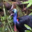
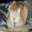
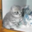
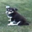
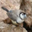
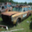
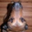
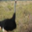
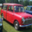
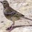
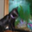
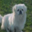
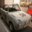
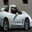
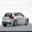
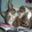
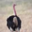
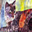
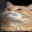
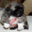

In [18]:
image_train[0:20].explore()

# Train an image classifier on raw image pixels

In [16]:
raw_pixel_model = turicreate.logistic_classifier.create(image_train,
                                                       target = 'label',
                                                       features = ['image_array'])

PROGRESS: Creating a validation set from 5 percent of training data. This may take a while.
          You can set ``validation_set=None`` to disable validation tracking.



Logistic regression:

--------------------------------------------------------

Number of examples          : 1904

Number of classes           : 4

...

| 2         | 11       | 1.805487  | 1.747472     | 0.385504          | 0.366337            |

| 3         | 17       | 0.525974  | 2.048191     | 0.446429          | 0.485149            |

| 4         | 24       | 10.406801 | 2.373057     | 0.457458          | 0.495050            |

| 9         | 36       | 1.000000  | 3.090413     | 0.546218          | 0.504950            |

+-----------+----------+-----------+--------------+-------------------+---------------------+

# Make predictions using simple raw pixel model

,image,label
0,,cat
1,,automobile
2,,cat

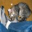
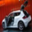
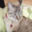

In [20]:
image_test[0:3]['image','label'].explore()

In [22]:
raw_pixel_model.predict(image_test[0:3])

dtype: str
Rows: 3
['dog', 'cat', 'bird']

# Evaluate the raw pixel model on the test data

In [23]:
raw_pixel_model.evaluate(image_test)

{'accuracy': 0.485,
 'auc': 0.7357339999999996,
 'confusion_matrix': Columns:
 	target_label	str
 	predicted_label	str
 	count	int
 
 Rows: 16
 
 Data:
 +--------------+-----------------+-------+
 | target_label | predicted_label | count |
 +--------------+-----------------+-------+
 |     cat      |       cat       |  306  |
 |     dog      |    automobile   |  107  |
 |     dog      |       bird      |  194  |
 |     cat      |    automobile   |  151  |
 |     dog      |       dog       |  493  |
 |     cat      |       dog       |  402  |
 |     bird     |    automobile   |  142  |
 |  automobile  |    automobile   |  672  |
 |     bird     |       cat       |  179  |
 |     dog      |       cat       |  206  |
 +--------------+-----------------+-------+
 [16 rows x 3 columns]
 Note: Only the head of the SFrame is printed.
 You can use print_rows(num_rows=m, num_columns=n) to print more rows and columns.,
 'f1_score': 0.4815259007716855,
 'log_loss': 1.177685752791608,
 'precision':

# Train image classifier using deep features

In [24]:
len(image_train)

2005

In [13]:
#deep_learning_model = turicreate.load_model('imagenet_model_iter45')
#image_train['deep_features'] = deep_learning_model.extract_features(image_train)

In [14]:
image_train

id,image,label,deep_features,image_array
24,Height: 32 Width: 32,bird,"[0.242871761322,1.09545373917, 0.0, ...","[73.0, 77.0, 58.0, 71.0,68.0, 50.0, 77.0, 69.0, ..."
33,Height: 32 Width: 32,cat,"[0.525087952614, 0.0,0.0, 0.0, 0.0, 0.0, ...","[7.0, 5.0, 8.0, 7.0, 5.0,8.0, 5.0, 4.0, 6.0, 7.0, ..."
36,Height: 32 Width: 32,cat,"[0.566015958786, 0.0,0.0, 0.0, 0.0, 0.0, ...","[169.0, 122.0, 65.0,131.0, 108.0, 75.0, ..."
70,Height: 32 Width: 32,dog,"[1.12979578972, 0.0, 0.0,0.778194487095, 0.0, ...","[154.0, 179.0, 152.0,159.0, 183.0, 157.0, ..."
90,Height: 32 Width: 32,bird,"[1.71786928177, 0.0, 0.0,0.0, 0.0, 0.0, ...","[216.0, 195.0, 180.0,201.0, 178.0, 160.0, ..."
97,Height: 32 Width: 32,automobile,"[1.57818555832, 0.0, 0.0,0.0, 0.0, 0.0, ...","[33.0, 44.0, 27.0, 29.0,44.0, 31.0, 32.0, 45.0, ..."
107,Height: 32 Width: 32,dog,"[0.0, 0.0,0.220677852631, 0.0, ...","[97.0, 51.0, 31.0, 104.0,58.0, 38.0, 107.0, 61.0, ..."
121,Height: 32 Width: 32,bird,"[0.0, 0.23753464222, 0.0,0.0, 0.0, 0.0, ...","[93.0, 96.0, 88.0, 102.0,106.0, 97.0, 117.0, ..."
136,Height: 32 Width: 32,automobile,"[0.0, 0.0, 0.0, 0.0, 0.0,0.0, 7.5737862587, 0.0, ...","[35.0, 59.0, 53.0, 36.0,56.0, 56.0, 42.0, 62.0, ..."
138,Height: 32 Width: 32,bird,"[0.658935725689, 0.0,0.0, 0.0, 0.0, 0.0, ...","[205.0, 193.0, 195.0,200.0, 187.0, 193.0, ..."


# Given the deep features, train a logistic classifier

In [25]:
deep_features_model = turicreate.logistic_classifier.create(image_train,
                                                           target='label',
                                                           features = ['deep_features'])

PROGRESS: Creating a validation set from 5 percent of training data. This may take a while.
          You can set ``validation_set=None`` to disable validation tracking.



Logistic regression:

--------------------------------------------------------

Number of examples          : 1904

Number of classes           : 4

...

| 2         | 8        | 0.263971  | 0.690338     | 0.777311          | 0.772277            |

| 3         | 12       | 0.791913  | 1.049722     | 0.776261          | 0.782178            |

| 4         | 13       | 0.989892  | 1.188802     | 0.807773          | 0.801980            |

| 9         | 20       | 1.000000  | 2.060917     | 0.913340          | 0.762376            |

+-----------+----------+-----------+--------------+-------------------+---------------------+

# Apply the deep features classifier on the first few images

,image,label
0,,cat
1,,automobile
2,,cat

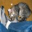
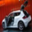
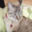

In [27]:
image_test[0:3]['image','label'].explore()

In [28]:
deep_features_model.predict(image_test[0:3])

dtype: str
Rows: 3
['cat', 'automobile', 'cat']

# Quantitatively evaluate deep features classifier on test data

In [29]:
deep_features_model.evaluate(image_test)

{'accuracy': 0.79225,
 'auc': 0.9419515833333327,
 'confusion_matrix': Columns:
 	target_label	str
 	predicted_label	str
 	count	int
 
 Rows: 16
 
 Data:
 +--------------+-----------------+-------+
 | target_label | predicted_label | count |
 +--------------+-----------------+-------+
 |     bird     |       cat       |  118  |
 |     dog      |    automobile   |   9   |
 |     cat      |    automobile   |   16  |
 |     dog      |       bird      |   60  |
 |     cat      |       bird      |   82  |
 |     bird     |       dog       |   47  |
 |  automobile  |       dog       |   6   |
 |  automobile  |       cat       |   24  |
 |     dog      |       cat       |  243  |
 |     cat      |       cat       |  709  |
 +--------------+-----------------+-------+
 [16 rows x 3 columns]
 Note: Only the head of the SFrame is printed.
 You can use print_rows(num_rows=m, num_columns=n) to print more rows and columns.,
 'f1_score': 0.7933176699107336,
 'log_loss': 0.5995434614473013,
 'precisio